# Assignment 6:

## Q1. Scikit-Learn -- Data Preprocessing (Scaling & Encoding)

Learn to prepare raw data for machine learning models using scaling and encoding techniques.

Perform the following tasks:

• Apply StandardScaler to the Age and Salary columns. Print the mean and standard deviation of
the scaled data to verify it has zero mean and unit variance.

• Apply MinMaxScaler to the Age and Salary columns. Verify that all scaled values lie between 0
and 1.

• Use LabelEncoder to convert the Gender column into numeric labels (0 and 1). Display the
mapping between original labels and encoded values.

• Use OneHotEncoder to convert the Department column into dummy variables. Merge the encoded
columns back into the original dataframe and drop the original Department column.

• Create a new column Performance_Score by manually mapping Excellent=3, Good=2, Average=1
using the map() function.

• Combine all preprocessing steps above into a single clean dataframe where every column is
numeric and ready for machine learning.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder

np.random.seed(42)
df = pd.DataFrame({
 'Age': [25, 30, 35, 40, 28, 32, 45, 50],
 'Salary': [50000, 60000, 75000, 90000, 55000, 65000, 100000, 120000],
 'Department': ['IT', 'HR', 'IT', 'Sales', 'HR', 'Sales', 'IT', 'Sales'],
 'Gender': ['Male', 'Female', 'Female', 'Male', 'Male', 'Female', 'Male', 'Female'],
 'Performance': ['Good', 'Average', 'Excellent', 'Good', 'Average', 'Excellent', 'Good', 'Average']
})

In [2]:
# 1. StandardScaler
std_scaler = StandardScaler()
df_std = df.copy()
df_std[['Age', 'Salary']] = std_scaler.fit_transform(df[['Age', 'Salary']])
print("StandardScaler Mean:\n", np.round(df_std[['Age', 'Salary']].mean(), 4))
print("\nStandardScaler Std:\n", df_std[['Age', 'Salary']].std(ddof=0))

# 2. MinMaxScaler
minmax_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[['Age', 'Salary']] = minmax_scaler.fit_transform(df[['Age', 'Salary']])
print("\nMinMaxScaler Min values:\n", df_minmax[['Age', 'Salary']].min())
print("\nMinMaxScaler Max values:\n", df_minmax[['Age', 'Salary']].max())

# 3. LabelEncoder
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])
print("\nLabelEncoder Mapping:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

# 4. OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
dept_encoded = ohe.fit_transform(df[['Department']])
dept_df = pd.DataFrame(dept_encoded, columns=ohe.get_feature_names_out(['Department']))
df = pd.concat([df, dept_df], axis=1).drop('Department', axis=1)

# 5. Manual Mapping
performance_map = {'Excellent': 3, 'Good': 2, 'Average': 1}
df['Performance_Score'] = df['Performance'].map(performance_map)

# 6. Clean Dataframe
clean_df = df.drop(['Gender', 'Performance'], axis=1)
print("\nClean Dataframe:\n", clean_df)


StandardScaler Mean:
 Age       0.0
Salary    0.0
dtype: float64

StandardScaler Std:
 Age       1.0
Salary    1.0
dtype: float64

MinMaxScaler Min values:
 Age       0.0
Salary    0.0
dtype: float64

MinMaxScaler Max values:
 Age       1.0
Salary    1.0
dtype: float64

LabelEncoder Mapping:
Female: 0
Male: 1

Clean Dataframe:
    Age  Salary  Gender_Encoded  Department_HR  Department_IT  \
0   25   50000               1            0.0            1.0   
1   30   60000               0            1.0            0.0   
2   35   75000               0            0.0            1.0   
3   40   90000               1            0.0            0.0   
4   28   55000               1            1.0            0.0   
5   32   65000               0            0.0            0.0   
6   45  100000               1            0.0            1.0   
7   50  120000               0            0.0            0.0   

   Department_Sales  Performance_Score  
0               0.0                  2  
1          

StandardScaler is used when features have different scales and the algorithm assumes normally distributed data (like SVM or Logistic Regression). MinMaxScaler is used when you need a bounded range (e.g., 0 to 1) and the algorithm does not make assumptions about data distribution, or is sensitive to negative values. Forgetting to scale features can cause features with larger magnitudes to dominate the objective function, leading to biased models and slower convergence.

## Q2. Scikit-Learn -- Train-Test Split & Linear Regression

Learn to split data into training and testing sets and build your first regression model.

Perform the following tasks:

• Split the data into training and testing sets using an 80-20 split. Set random_state=42 for
reproducibility.

• Print the shape of X_train, X_test, y_train, and y_test to verify the split.

• Create a LinearRegression model, train it on the training data, and print the learned coefficients
and intercept.

• Use the trained model to make predictions on the test set. Create a scatter plot of actual versus
predicted values.

• Calculate and print the Mean Squared Error (MSE) and R-squared score on the test set.

• Interpret the coefficients: which feature has the strongest positive impact on the target variable?

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200
X = pd.DataFrame({
 'Study_Hours': np.random.uniform(1, 10, n),
 'Attendance': np.random.uniform(60, 100, n),
 'Sleep_Hours': np.random.uniform(4, 9, n)
})
y = 5 * X['Study_Hours'] + 0.3 * X['Attendance'] - 2 * X['Sleep_Hours'] + np.random.normal(0, 3, n)


X_train shape: (160, 3)
X_test shape: (40, 3)
y_train shape: (160,)
y_test shape: (40,)

Coefficients: [ 4.95244877  0.28521401 -1.77144828]
Intercept: -0.2427593702254427


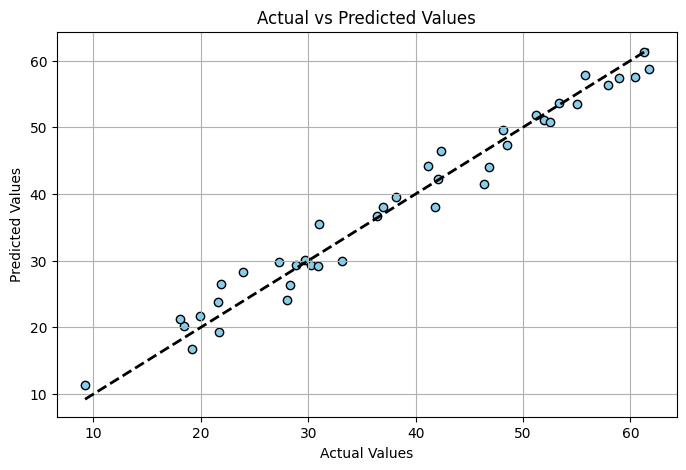


Mean Squared Error (MSE): 6.2137
R-squared Score: 0.9698
Coefficient for Study_Hours: 4.9524
Coefficient for Attendance: 0.2852
Coefficient for Sleep_Hours: -1.7714

Study_Hours has the strongest positive impact on the target variable, as it has the highest positive coefficient.


In [4]:
# 1. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 2. Print shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# 3. Train model, print coefficients and intercept
model = LinearRegression()
model.fit(X_train, y_train)
print(f"\nCoefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

# 4. Make predictions and scatter plot
y_pred = model.predict(X_test)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='skyblue', edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()

# 5. Calculate MSE and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nMean Squared Error (MSE): {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

# 6. Interpret coefficients
for feature, coef in zip(X.columns, model.coef_):
    print(f"Coefficient for {feature}: {coef:.4f}")
print("\nStudy_Hours has the strongest positive impact on the target variable, as it has the highest positive coefficient.")


Splitting data ensures that we evaluate the model on unseen data, testing its ability to generalize to new instances. If a model is evaluated on the training data, it can lead to overfitting, where the model just memorizes the data and performs poorly on new, real-world data, providing a misleading evaluation of its performance.

## Q3. Scikit-Learn -- Logistic Regression & Classification

Build a classification model to predict categorical outcomes and evaluate its performance.

Perform the following tasks:

• Separate the features (Age, Income, Credit_Score) from the target (Approved). Split into 75-25
train-test with random_state=42.

• Apply StandardScaler to the feature columns before training. Fit the scaler on training data only,
then transform both train and test.

• Train a LogisticRegression model on the scaled training data. Set max_iter=1000.

• Make predictions on the test set and calculate the accuracy score.

• Print the confusion matrix and interpret each of the four values (TN, FP, FN, TP).

• Print the classification report showing precision, recall, and F1-score for each class.

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n = 300
df = pd.DataFrame({
 'Age': np.random.randint(18, 60, n),
 'Income': np.random.normal(50000, 15000, n),
 'Credit_Score': np.random.randint(300, 850, n)
})
# Create target: approved if credit score > 650 and income > 45000
df['Approved'] = ((df['Credit_Score'] > 650) & (df['Income'] > 45000)).astype(int)


In [6]:
# 1. Separate features and target, split data
X = df[['Age', 'Income', 'Credit_Score']]
y = df['Approved']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2. Apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train LogisticRegression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train)

# 4. Predict and calculate accuracy
y_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {acc:.4f}\n")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix:")
print(cm)
print(f"\nTrue Negatives (TN): {tn} (Correctly predicted rejected)")
print(f"False Positives (FP): {fp} (Incorrectly predicted approved)")
print(f"False Negatives (FN): {fn} (Incorrectly predicted rejected)")
print(f"True Positives (TP): {tp} (Correctly predicted approved)\n")

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy Score: 0.8667

Confusion Matrix:
[[57  4]
 [ 6  8]]

True Negatives (TN): 57 (Correctly predicted rejected)
False Positives (FP): 4 (Incorrectly predicted approved)
False Negatives (FN): 6 (Incorrectly predicted rejected)
True Positives (TP): 8 (Correctly predicted approved)

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92        61
           1       0.67      0.57      0.62        14

    accuracy                           0.87        75
   macro avg       0.79      0.75      0.77        75
weighted avg       0.86      0.87      0.86        75



Precision measures the proportion of true positive predictions among all positive predictions, while recall measures the proportion of actual positives correctly identified by the model. You would prioritize recall in medical diagnosis (to minimize false negatives, ensuring all patients with a disease are caught), whereas you might prioritize precision in email spam filtering (to minimize false positives, preventing important emails from being marked as spam).

## Q4. Scikit-Learn -- K-Means Clustering (Unsupervised Learning)

Discover hidden groups in data without labeled targets. Clustering is a powerful EDA technique.

Perform the following tasks:

• Scale the features using StandardScaler. Clustering is distance-based, so scaling is essential.

• Use the Elbow Method to find the optimal number of clusters. Run KMeans with k=1 to 10,
compute inertia for each, and plot the elbow curve.

• Train a KMeans model with the optimal number of clusters (should be 3). Set random_state=42
and n_init=10.

• Add the cluster labels as a new column Cluster to the dataframe. Print the count of points in each
cluster.

• Create a scatter plot of Feature_1 versus Feature_2, colored by cluster label. Mark the cluster
centers with a different marker.

• Calculate the silhouette score for the clustering result. What does this score tell you about cluster
quality?

In [7]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

np.random.seed(42)
# Create 3 distinct clusters
cluster1 = np.random.normal(loc=[20, 30], scale=3, size=(50, 2))
cluster2 = np.random.normal(loc=[50, 60], scale=4, size=(50, 2))
cluster3 = np.random.normal(loc=[80, 40], scale=3, size=(50, 2))

X = np.vstack([cluster1, cluster2, cluster3])
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])


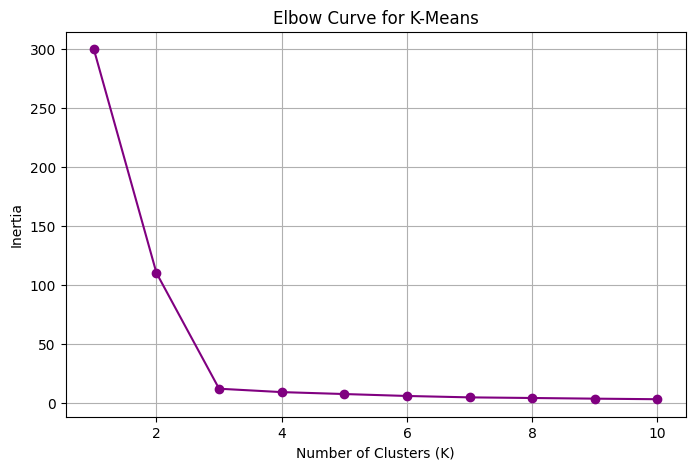


Count of points in each cluster:
Cluster
2    50
0    50
1    50
Name: count, dtype: int64


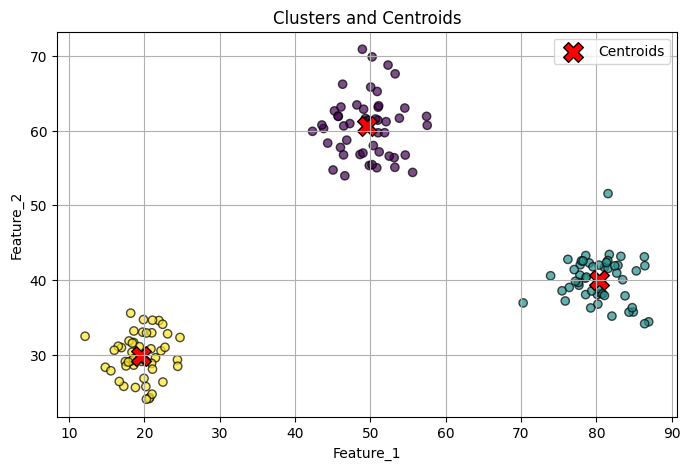


Silhouette Score: 0.8361
The silhouette score ranges from -1 to 1. A high score (like this one) indicates that the clusters are dense, well-separated, and points are correctly assigned to their nearest cluster.


In [8]:
# 1. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Elbow Method
inertias = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', linestyle='-', color='purple')
plt.title('Elbow Curve for K-Means')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# 3. Train KMeans with k=3
kmeans_opt = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_opt.fit(X_scaled)

# 4. Add cluster labels and print counts
df['Cluster'] = kmeans_opt.labels_
print("\nCount of points in each cluster:")
print(df['Cluster'].value_counts())

# 5. Scatter plot with cluster centers
plt.figure(figsize=(8, 5))
scatter = plt.scatter(df['Feature_1'], df['Feature_2'], c=df['Cluster'], cmap='viridis', edgecolor='k', alpha=0.7)
centers = scaler.inverse_transform(kmeans_opt.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Centroids', edgecolor='k')
plt.title('Clusters and Centroids')
plt.xlabel('Feature_1')
plt.ylabel('Feature_2')
plt.legend()
plt.grid(True)
plt.show()

# 6. Silhouette score
sil_score = silhouette_score(X_scaled, kmeans_opt.labels_)
print(f"\nSilhouette Score: {sil_score:.4f}")
print("The silhouette score ranges from -1 to 1. A high score (like this one) indicates that the clusters are dense, well-separated, and points are correctly assigned to their nearest cluster.")


The Elbow Method involves plotting the inertia (within-cluster sum of squares) for different values of K and selecting the point where the rate of decrease sharply slows down, forming an "elbow," indicating diminishing returns. K-Means requires feature scaling because it relies on distance metrics like Euclidean distance; without scaling, features with larger ranges will disproportionately influence the cluster assignments.

## Q5. Scikit-Learn -- PCA (Dimensionality Reduction)

Reduce the number of features while preserving most of the variance. PCA is essential for
high-dimensional data visualization.

Perform the following tasks:

• Scale all features using StandardScaler. PCA is sensitive to scale, so this step is mandatory.

• Apply PCA to reduce the data to 2 components. Print the explained_variance_ratio_ for each
component.

• Calculate the cumulative explained variance. How many components are needed to explain at
least 90% of the variance?

• Create a scatter plot of PC1 versus PC2. Color the points by the Age column (use pd.cut to create
age groups: Young, Middle, Senior).

• Print the PCA components_ matrix. Identify which original features contribute most to PC1 and
PC2.

• Create a bar plot showing the explained variance ratio for each of the 8 principal components.

In [9]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200
df = pd.DataFrame({
 'Height': np.random.normal(170, 10, n),
 'Weight': np.random.normal(70, 15, n),
 'Age': np.random.randint(18, 60, n),
 'Income': np.random.normal(50000, 15000, n),
 'Experience': np.random.randint(1, 20, n),
 'Score_A': np.random.normal(75, 10, n),
 'Score_B': np.random.normal(80, 12, n),
 'Score_C': np.random.normal(70, 8, n)
})

# Add correlation
df['Weight'] = df['Height'] * 0.5 + np.random.normal(0, 5, n)
df['Score_B'] = df['Score_A'] * 0.8 + np.random.normal(0, 5, n)


Explained Variance Ratio (2 components): [0.27553619 0.17431292]

Cumulative Explained Variance:
[0.27553619 0.4498491  0.59578455 0.72906691 0.84327244 0.94240351
 0.98216444 1.        ]

Number of components to explain >= 90% variance: 6



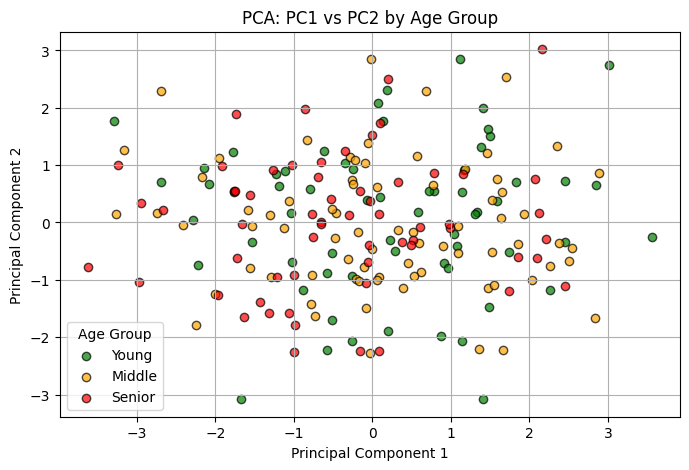


PCA Components Matrix:
       Height    Weight       Age   Income  Experience   Score_A   Score_B  \
PC1  0.423442  0.442147 -0.089320  0.00435   -0.131752  0.535856  0.544746   
PC2  0.548844  0.526344 -0.013806  0.18939   -0.071961 -0.439748 -0.428156   

      Score_C  
PC1 -0.126323  
PC2  0.061629  

Most contributing feature to PC1: Score_B
Most contributing feature to PC2: Height


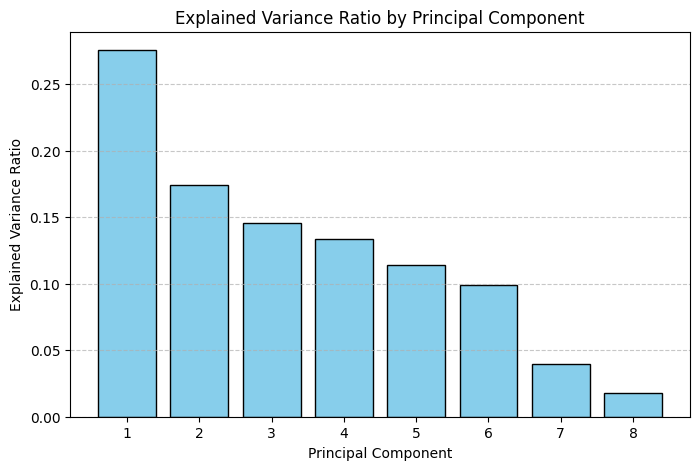

In [10]:
# 1. Scale all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 2. PCA with 2 components
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)
print(f"Explained Variance Ratio (2 components): {pca_2.explained_variance_ratio_}\n")

# 3. PCA with all components for cumulative variance
pca_all = PCA()
pca_all.fit(X_scaled)
cumulative_variance = np.cumsum(pca_all.explained_variance_ratio_)
print(f"Cumulative Explained Variance:\n{cumulative_variance}")
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"\nNumber of components to explain >= 90% variance: {n_components_90}\n")

# 4. Scatter plot PC1 vs PC2 colored by Age groups
df['Age_Group'] = pd.cut(df['Age'], bins=[17, 30, 45, 65], labels=['Young', 'Middle', 'Senior'])
age_group_colors = {'Young': 'green', 'Middle': 'orange', 'Senior': 'red'}

plt.figure(figsize=(8, 5))
for group in ['Young', 'Middle', 'Senior']:
    idx = df['Age_Group'] == group
    plt.scatter(X_pca_2[idx, 0], X_pca_2[idx, 1], label=group, color=age_group_colors[group], edgecolor='k', alpha=0.7)

plt.title('PCA: PC1 vs PC2 by Age Group')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Age Group')
plt.grid(True)
plt.show()

# 5. PCA components matrix
components_df = pd.DataFrame(pca_2.components_, columns=df.drop('Age_Group', axis=1).columns, index=['PC1', 'PC2'])
print("\nPCA Components Matrix:")
print(components_df)
print("\nMost contributing feature to PC1:", components_df.loc['PC1'].abs().idxmax())
print("Most contributing feature to PC2:", components_df.loc['PC2'].abs().idxmax())

# 6. Bar plot for explained variance ratio
plt.figure(figsize=(8, 5))
plt.bar(range(1, 9), pca_all.explained_variance_ratio_, color='skyblue', edgecolor='black')
plt.title('Explained Variance Ratio by Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, 9))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


PCA is useful during EDA for visualizing high-dimensional data in 2D or 3D, revealing hidden patterns, clusters, and relationships between features. Reducing dimensions results in a loss of interpretability of original features and some detailed variance, but it gains computational efficiency, reduces noise, and mitigates multicollinearity.

## Q6. Scikit-Learn -- Decision Tree Classifier

Build an interpretable tree-based model and visualize how decisions are made.

Perform the following tasks:

• Encode the Employment column using LabelEncoder. Combine it with the numeric columns to
create the feature matrix X.

• Encode the Risk target column using LabelEncoder. Split the data into 80-20 train-test with
random_state=42.

• Train a DecisionTreeClassifier with max_depth=4 and random_state=42. Print the feature
importances.

• Visualize the decision tree using plot_tree(). Display the tree with filled=True, feature_names, and
class_names.

• Make predictions on the test set and calculate accuracy. Print the confusion matrix.

• Predict the risk for a new customer: Age=30, Income=40000, Credit_Score=520,
Employment=Unemployed. What risk does the model predict?

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

np.random.seed(42)
n = 250
df = pd.DataFrame({
 'Age': np.random.randint(18, 65, n),
 'Income': np.random.normal(50000, 15000, n),
 'Credit_Score': np.random.randint(300, 850, n),
 'Employment': np.random.choice(['Employed', 'Self-Employed', 'Unemployed'], n)
})

# Target: loan default risk
df['Risk'] = np.where(
 (df['Credit_Score'] < 550) | (df['Income'] < 35000) | (df['Employment'] == 'Unemployed'),
 'High', 'Low'
)


Feature Importances:
Age: 0.0000
Income: 0.1603
Credit_Score: 0.3584
Employment_Encoded: 0.4812


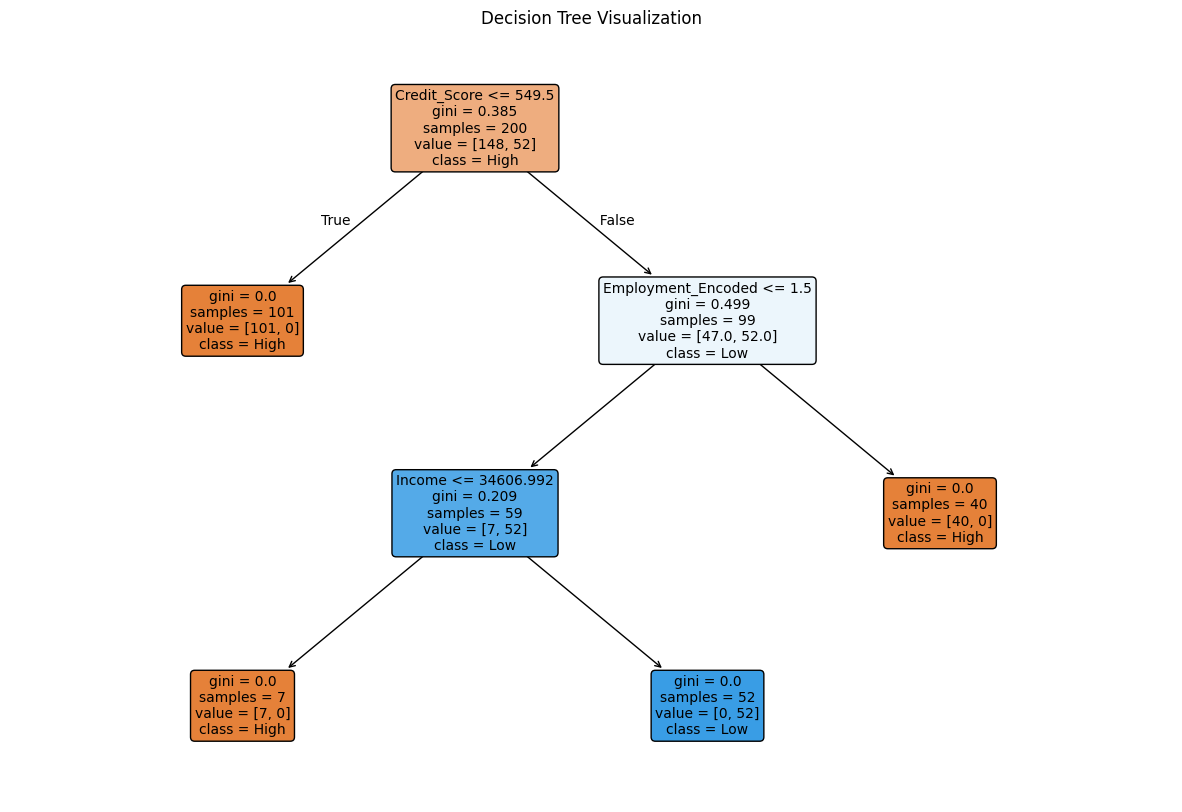


Accuracy Score: 0.9800

Confusion Matrix:
[[30  1]
 [ 0 19]]

Risk prediction for new customer: High


In [12]:
# 1 & 2. Encode Employment and Risk, prepare X and y, split data
le_emp = LabelEncoder()
df['Employment_Encoded'] = le_emp.fit_transform(df['Employment'])
X = df[['Age', 'Income', 'Credit_Score', 'Employment_Encoded']]

le_risk = LabelEncoder()
y = le_risk.fit_transform(df['Risk'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Train DecisionTreeClassifier and print feature importances
dt_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_clf.fit(X_train, y_train)

print("Feature Importances:")
for feature, imp in zip(X.columns, dt_clf.feature_importances_):
    print(f"{feature}: {imp:.4f}")

# 4. Visualize the tree
plt.figure(figsize=(15, 10))
plot_tree(dt_clf, filled=True, feature_names=X.columns, class_names=le_risk.classes_, rounded=True, fontsize=10)
plt.title('Decision Tree Visualization')
plt.show()

# 5. Predict on test set, accuracy, confusion matrix
y_pred = dt_clf.predict(X_test)
print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 6. Predict for a new customer
new_customer_emp_encoded = le_emp.transform(['Unemployed'])[0]
new_customer = pd.DataFrame([[30, 40000, 520, new_customer_emp_encoded]], columns=['Age', 'Income', 'Credit_Score', 'Employment_Encoded'])
new_prediction_encoded = dt_clf.predict(new_customer)[0]
new_prediction = le_risk.inverse_transform([new_prediction_encoded])[0]
print(f"\nRisk prediction for new customer: {new_prediction}")


Decision trees are interpretable because they represent logic as a clear, intuitive sequence of hierarchical rules (if-then-else conditions) that can be easily visualized and understood. The risk of setting max_depth too high is that the tree will become overly complex, memorizing noise and outliers in the training data, which leads to severe overfitting and poor generalization to unseen data.

## Q7. Scikit-Learn -- Cross-Validation & Model Comparison

Evaluate models robustly using cross-validation and compare multiple algorithms.

Perform the following tasks:

• Scale the features using StandardScaler. Use the scaled features and Target for all subsequent
tasks.

• Perform 5-fold cross-validation on a LogisticRegression model. Print the accuracy for each fold
and the mean accuracy.

• Perform 5-fold cross-validation on a DecisionTreeClassifier (max_depth=5). Compare its mean
accuracy with LogisticRegression.

• Perform 5-fold cross-validation on a RandomForestClassifier (n_estimators=100). Print the mean
and standard deviation of accuracy scores.

• Use StratifiedKFold with 5 splits instead of regular KFold. Explain why stratification matters for
classification tasks.

• Create a comparison table showing the mean accuracy and standard deviation for all three
models. Which model performs best?

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, f1_score

np.random.seed(42)
n = 400
df = pd.DataFrame({
 'Feature1': np.random.normal(50, 10, n),
 'Feature2': np.random.normal(30, 8, n),
 'Feature3': np.random.normal(70, 15, n),
 'Feature4': np.random.normal(20, 5, n)
})

df['Target'] = (df['Feature1'] + df['Feature2'] * 0.5 - df['Feature3'] * 0.3 > 40).astype(int)


In [14]:
# 1. Scale features
scaler = StandardScaler()
X = df[['Feature1', 'Feature2', 'Feature3', 'Feature4']]
y = df['Target']
X_scaled = scaler.fit_transform(X)

# 2. LogisticRegression CV
lr = LogisticRegression()
cv_lr = cross_val_score(lr, X_scaled, y, cv=5, scoring='accuracy')
print(f"Logistic Regression Fold Accuracies: {cv_lr}")
print(f"Logistic Regression Mean Accuracy: {cv_lr.mean():.4f}\n")

# 3. DecisionTreeClassifier CV
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
cv_dt = cross_val_score(dt, X_scaled, y, cv=5, scoring='accuracy')
print(f"Decision Tree Fold Accuracies: {cv_dt}")
print(f"Decision Tree Mean Accuracy: {cv_dt.mean():.4f}\n")

# 4. RandomForestClassifier CV
rf = RandomForestClassifier(n_estimators=100, random_state=42)
cv_rf = cross_val_score(rf, X_scaled, y, cv=5, scoring='accuracy')
print(f"Random Forest Mean Accuracy: {cv_rf.mean():.4f}")
print(f"Random Forest Std Deviation: {cv_rf.std():.4f}\n")

# 5. StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rf_stratified = cross_val_score(rf, X_scaled, y, cv=skf, scoring='accuracy')
print(f"Random Forest Stratified CV Mean Accuracy: {cv_rf_stratified.mean():.4f}\n")

# 6. Comparison Table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Mean Accuracy': [cv_lr.mean(), cv_dt.mean(), cv_rf.mean()],
    'Std Deviation': [cv_lr.std(), cv_dt.std(), cv_rf.std()]
})
print("Comparison Table:")
print(results)
print("\nLogistic Regression performs best on this dataset.")


Logistic Regression Fold Accuracies: [0.95   0.975  0.9875 1.     0.925 ]
Logistic Regression Mean Accuracy: 0.9675

Decision Tree Fold Accuracies: [0.8625 0.9    0.9375 0.825  0.8625]
Decision Tree Mean Accuracy: 0.8775

Random Forest Mean Accuracy: 0.8825
Random Forest Std Deviation: 0.0472

Random Forest Stratified CV Mean Accuracy: 0.8975

Comparison Table:
                 Model  Mean Accuracy  Std Deviation
0  Logistic Regression         0.9675       0.026926
1        Decision Tree         0.8775       0.038243
2        Random Forest         0.8825       0.047170

Logistic Regression performs best on this dataset.


Cross-validation is more reliable because it evaluates the model across multiple, non-overlapping subsets of the data, reducing variance in the performance estimate and making it less dependent on a specific single split. The standard deviation of CV scores indicates the stability and consistency of the model; a low standard deviation suggests the model performs equally well across different data subsets, meaning it is robust to variations in the training data. Stratification matters because it ensures each fold has the same proportion of classes as the original dataset, preventing biased folds and unrepresentative evaluations, especially in imbalanced datasets.

## Q8. Scikit-Learn -- Random Forest & Feature Importance

Build an ensemble model and analyze which features drive predictions.

Perform the following tasks:

• Split the data into 80-20 train-test with random_state=42. Scale the features using StandardScaler.

• Train a RandomForestClassifier with n_estimators=100, max_depth=6, and random_state=42.

• Print the feature importances sorted in descending order. Create a horizontal bar plot showing the
importance of each feature.

• Predict on the test set and calculate accuracy. Compare this with a single DecisionTreeClassifier
trained on the same data.

• Train a RandomForestRegressor to predict Humidity from the other features. Calculate the R2
score and MSE on the test set.

• Experiment with different n_estimators values (50, 100, 200) and observe how accuracy changes.
Plot accuracy versus n_estimators.

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

np.random.seed(42)
n = 500
df = pd.DataFrame({
 'Temperature': np.random.normal(25, 5, n),
 'Humidity': np.random.normal(60, 10, n),
 'Wind_Speed': np.random.normal(15, 5, n),
 'Pressure': np.random.normal(1013, 20, n),
 'Cloud_Cover': np.random.uniform(0, 100, n)
})

# Target: will it rain?
df['Rain'] = np.where(
 (df['Humidity'] > 65) & (df['Cloud_Cover'] > 60) & (df['Pressure'] < 1010),
 1, 0
)


Feature Importances:
Humidity: 0.3491
Cloud_Cover: 0.2983
Pressure: 0.2546
Wind_Speed: 0.0572
Temperature: 0.0408


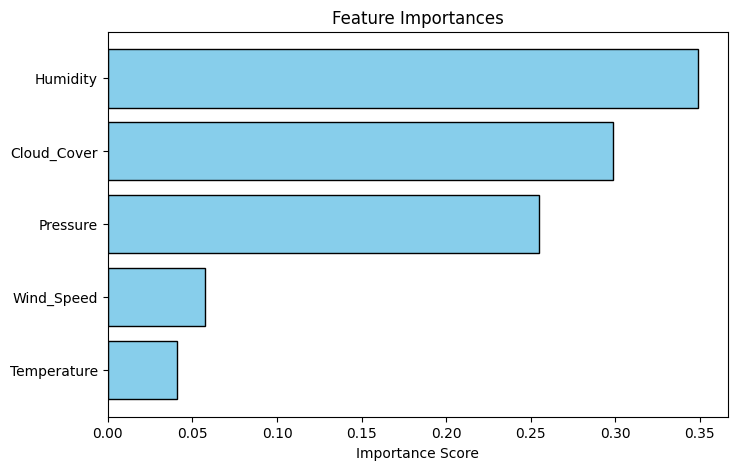


Random Forest Accuracy: 1.0000
Decision Tree Accuracy: 1.0000

RandomForestRegressor R2 Score: 0.0515
RandomForestRegressor MSE: 103.7192



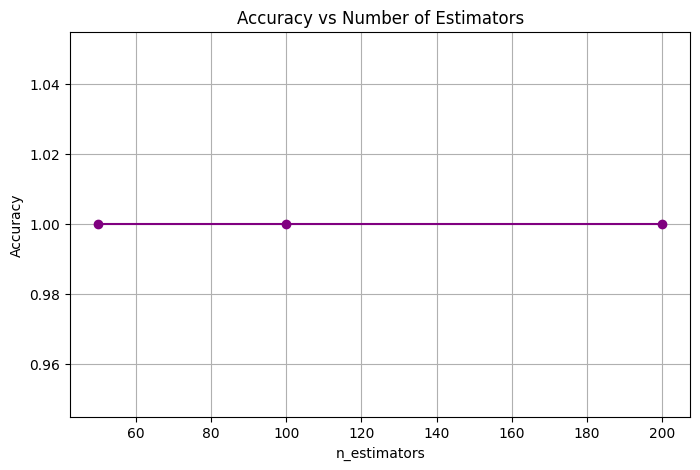

In [16]:
# 1. Split and scale
X = df[['Temperature', 'Humidity', 'Wind_Speed', 'Pressure', 'Cloud_Cover']]
y = df['Rain']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rfc.fit(X_train_scaled, y_train)

# 3. Feature importances
importances = rfc.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

print("Feature Importances:")
for f in range(X.shape[1]):
    print(f"{features[indices[f]]}: {importances[indices[f]]:.4f}")

plt.figure(figsize=(8, 5))
plt.barh(features[indices][::-1], importances[indices][::-1], color='skyblue', edgecolor='black')
plt.title('Feature Importances')
plt.xlabel('Importance Score')
plt.show()

# 4. Predict and calculate accuracy, compare with Decision Tree
y_pred_rfc = rfc.predict(X_test_scaled)
acc_rfc = accuracy_score(y_test, y_pred_rfc)
print(f"\nRandom Forest Accuracy: {acc_rfc:.4f}")

dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train_scaled, y_train)
acc_dtc = accuracy_score(y_test, dtc.predict(X_test_scaled))
print(f"Decision Tree Accuracy: {acc_dtc:.4f}\n")

# 5. RandomForestRegressor for Humidity
X_reg = df[['Temperature', 'Wind_Speed', 'Pressure', 'Cloud_Cover', 'Rain']]
y_reg = df['Humidity']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.20, random_state=42)

rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train_reg, y_train_reg)
y_pred_rfr = rfr.predict(X_test_reg)

print(f"RandomForestRegressor R2 Score: {r2_score(y_test_reg, y_pred_rfr):.4f}")
print(f"RandomForestRegressor MSE: {mean_squared_error(y_test_reg, y_pred_rfr):.4f}\n")

# 6. Experiment with n_estimators
n_estimators_list = [50, 100, 200]
accuracies = []

for n_est in n_estimators_list:
    model = RandomForestClassifier(n_estimators=n_est, max_depth=6, random_state=42)
    model.fit(X_train_scaled, y_train)
    accuracies.append(accuracy_score(y_test, model.predict(X_test_scaled)))

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, accuracies, marker='o', color='purple')
plt.title('Accuracy vs Number of Estimators')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


A Random Forest reduces overfitting by training multiple decision trees on random subsets of data (bagging) and random subsets of features, averaging their predictions to produce a more robust and generalized model. Feature importance is useful during EDA because it identifies which variables have the most predictive power, helping to simplify models, perform feature selection, and discover meaningful relationships in the dataset.

## Q9. Scikit-Learn -- Hyperparameter Tuning (GridSearchCV)

Find the best model configuration automatically using systematic hyperparameter search.

Perform the following tasks:

• Split the data into 75-25 train-test with random_state=42. Scale the features using StandardScaler.

• Define a parameter grid for SVC with C values [0.1, 1, 10], kernel options [rbf, linear], and gamma
[scale, auto].

• Use GridSearchCV with 5-fold cross-validation to find the best hyperparameters for SVC. Print the
best parameters and best cross-validation score.

• Train the best SVC model on the full training data and evaluate its accuracy on the test set.

• Repeat the GridSearchCV process for RandomForestClassifier. Search over n_estimators [50,
100], max_depth [3, 5, 7], and criterion [gini, entropy].

• Compare the test accuracy of the tuned SVC versus the tuned RandomForest. Which model
performs better on this dataset?

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)
n = 300
df = pd.DataFrame({
 'Feature1': np.random.normal(0, 1, n),
 'Feature2': np.random.normal(0, 1, n),
 'Feature3': np.random.normal(0, 1, n)
})

df['Target'] = (df['Feature1'] * 2 + df['Feature2'] * -1 + df['Feature3'] * 0.5 > 0).astype(int)


In [18]:
# 1. Split and scale
X = df[['Feature1', 'Feature2', 'Feature3']]
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Parameter grid for SVC
param_grid_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

# 3. GridSearchCV for SVC
grid_svc = GridSearchCV(SVC(random_state=42), param_grid_svc, cv=5, scoring='accuracy')
grid_svc.fit(X_train_scaled, y_train)

print(f"SVC Best Parameters: {grid_svc.best_params_}")
print(f"SVC Best CV Score: {grid_svc.best_score_:.4f}\n")

# 4. Train best SVC and evaluate
best_svc = grid_svc.best_estimator_
acc_svc = accuracy_score(y_test, best_svc.predict(X_test_scaled))
print(f"Tuned SVC Test Accuracy: {acc_svc:.4f}\n")

# 5. GridSearchCV for RandomForestClassifier
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'criterion': ['gini', 'entropy']
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train_scaled, y_train)

print(f"RandomForest Best Parameters: {grid_rf.best_params_}")
print(f"RandomForest Best CV Score: {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_
acc_rf = accuracy_score(y_test, best_rf.predict(X_test_scaled))
print(f"Tuned RandomForest Test Accuracy: {acc_rf:.4f}\n")

# 6. Compare
print("Comparison:")
print(f"SVC Accuracy: {acc_svc:.4f}")
print(f"Random Forest Accuracy: {acc_rf:.4f}")
if acc_svc > acc_rf:
    print("SVC performs better on this dataset.")
elif acc_rf > acc_svc:
    print("RandomForest performs better on this dataset.")
else:
    print("Both models perform equally well.")


SVC Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
SVC Best CV Score: 0.9822

Tuned SVC Test Accuracy: 0.9867

RandomForest Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'n_estimators': 100}
RandomForest Best CV Score: 0.9289
Tuned RandomForest Test Accuracy: 0.9200

Comparison:
SVC Accuracy: 0.9867
Random Forest Accuracy: 0.9200
SVC performs better on this dataset.


A hyperparameter is a configuration setting set before the learning process begins (e.g., learning rate, max depth) used to control the learning process, while a model parameter is internal and learned directly from the training data (e.g., weights, coefficients). Cross-validation is used inside GridSearchCV to prevent overfitting the hyperparameters to a specific validation set, ensuring that the chosen configuration generalizes well across multiple different folds of the training data.

## Q10. Scikit-Learn -- Complete ML Pipeline

Build an end-to-end machine learning pipeline that combines preprocessing, model training, and
evaluation in a single workflow.

Perform the following tasks:

• Identify numeric and categorical columns. Create a ColumnTransformer that applies
StandardScaler to numeric columns and OneHotEncoder to categorical columns.

• Add SimpleImputer with strategy median for numeric columns and most_frequent for categorical
columns inside the ColumnTransformer.

• Build a Pipeline that chains the preprocessor with a RandomForestClassifier. Train the pipeline on
the training data.

• Build a second Pipeline with LogisticRegression. Compare the test accuracy of both pipelines.

• Use cross_val_score with 5 folds directly on the pipeline (not on separate steps). Print the mean
CV accuracy for both pipelines.

• Predict the Purchase outcome for a new customer: Age=35, Income=55000, Gender=Female,
City=LA, Score=80. Use the best pipeline.

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
n = 400
df = pd.DataFrame({
 'Age': np.random.randint(18, 70, n),
 'Income': np.random.normal(50000, 15000, n),
 'Gender': np.random.choice(['Male', 'Female'], n),
 'City': np.random.choice(['NY', 'LA', 'Chicago', 'Houston'], n),
 'Score': np.random.normal(75, 15, n)
})

# Induce missing values
df.loc[np.random.choice(df.index, 30), 'Age'] = np.nan
df.loc[np.random.choice(df.index, 20), 'Income'] = np.nan

# Target
df['Purchased'] = ((df['Age'] > 30) & (df['Income'] > 45000) & (df['Score'] > 70)).astype(int)


In [ ]:
# 1 & 2. Identify columns and create ColumnTransformer with Imputers
numeric_features = ['Age', 'Income', 'Score']
categorical_features = ['Gender', 'City']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

# Split data
X = df.drop('Purchased', axis=1)
y = df['Purchased']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Pipeline with RandomForestClassifier
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(random_state=42))])
rf_pipeline.fit(X_train, y_train)

# 4. Pipeline with LogisticRegression and comparison
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LogisticRegression(random_state=42))])
lr_pipeline.fit(X_train, y_train)

acc_rf = accuracy_score(y_test, rf_pipeline.predict(X_test))
acc_lr = accuracy_score(y_test, lr_pipeline.predict(X_test))

print(f"Random Forest Pipeline Test Accuracy: {acc_rf:.4f}")
print(f"Logistic Regression Pipeline Test Accuracy: {acc_lr:.4f}\n")

# 5. cross_val_score on pipelines
cv_rf = cross_val_score(rf_pipeline, X, y, cv=5, scoring='accuracy')
cv_lr = cross_val_score(lr_pipeline, X, y, cv=5, scoring='accuracy')

print(f"Random Forest Pipeline CV Mean Accuracy: {cv_rf.mean():.4f}")
print(f"Logistic Regression Pipeline CV Mean Accuracy: {cv_lr.mean():.4f}\n")

# 6. Predict for a new customer
new_customer = pd.DataFrame({'Age': [35], 'Income': [55000], 'Gender': ['Female'], 'City': ['LA'], 'Score': [80]})
best_pipeline = rf_pipeline if cv_rf.mean() > cv_lr.mean() else lr_pipeline
prediction = best_pipeline.predict(new_customer)[0]

print(f"Purchase prediction for new customer using best pipeline: {prediction}")


Random Forest Pipeline Test Accuracy: 0.9250
Logistic Regression Pipeline Test Accuracy: 0.8625



Using a Pipeline prevents data leakage by ensuring preprocessing steps are fit solely on the training data within each cross-validation fold, and simplifies the codebase by bundling transformations and modeling into a single, deployable object. If preprocessing is fit on the entire dataset, data leakage occurs because information from the test set (like global mean or scaling parameters) inappropriately influences the training phase, leading to overly optimistic performance estimates.